# 🛠️ Wildfire Prediction - Phase 2: Feature Engineering

## Learning Objectives

By the end of this notebook, you will understand:

1. **How to extract weather data from ERA5**
2. **How to calculate vegetation indices (NDVI)**
3. **How to derive topographic features (slope, aspect)**
4. **How to create temporal features (lags, rolling windows)**
5. **How to join multiple data sources spatiotemporally**
6. **How to create the final training dataset**

---

## What We're Building

**Input**: Fire locations from Phase 1

**Output**: Training dataset where each row has:
```
cell_id | date | temp | humidity | wind | ndvi | slope | fire_7d_ahead
```

**Key insight**: We need features from BEFORE the fire to predict it (no look-ahead bias!).

---
## Step 1: Setup and Load Previous Work

In [1]:
# Core libraries
import ee
import pandas as pd
import numpy as np
import geopandas as gpd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # Progress bars
import time
# Initialize Earth Engine
ee.Initialize(project='wildfire-prediction-ml-project')
print("✅ Earth Engine initialized")

# Load grid from Phase 1
grid = pd.read_parquet('/home/krithi/Desktop/wildfire-prediction/files/data/grid_10km.parquet')
print(f"✅ Loaded grid: {len(grid):,} cells")

/home/krithi/Desktop/wildfire-prediction/files/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✅ Earth Engine initialized
✅ Loaded grid: 12,402 cells


### 🧠 **What We're Loading**

- **Grid**: The 10km × 10km cells we created in Phase 1
- **tqdm**: Gives us progress bars (helpful when processing many dates)
- We'll extract features for each grid cell on each date

---
## Step 2: Extract Weather Features

We'll use **ERA5-Land** - hourly weather reanalysis at 9km resolution.

In [2]:
def extract_weather_for_date(date_str, grid_cells, bbox):
    """
    Extract weather variables for all grid cells on a specific date.
    
    Parameters:
    -----------
    date_str : str
        Date in 'YYYY-MM-DD' format
    grid_cells : GeoDataFrame
        Grid cells with geometry
    bbox : list
        Bounding box [west, south, east, north]
    
    Returns:
    --------
    pandas.DataFrame
        Weather features for each grid cell
    
    How it works:
    -------------
    1. Load ERA5 for the specific date
    2. Calculate daily statistics (mean, max, min)
    3. Sample at grid cell centers
    4. Return as pandas DataFrame
    """
    
    # Load ERA5-Land hourly data
    # This dataset has weather variables at 9km resolution
    era5 = ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY') \
        .filterDate(date_str, ee.Date(date_str).advance(1, 'day')) \
        .filterBounds(ee.Geometry.Rectangle(bbox))
    
    # Select relevant bands
    # Full list: https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_HOURLY
    weather = era5.select([
        'temperature_2m',           # Temperature at 2m height (Kelvin)
        'dewpoint_temperature_2m',  # Dew point (Kelvin)
        'u_component_of_wind_10m',  # Wind U component (m/s)
        'v_component_of_wind_10m',  # Wind V component (m/s)
        'total_precipitation'       # Precipitation (meters)
    ])
    
    # Calculate daily statistics
    # .mean() averages across all hours in the day
    temp_mean = weather.select('temperature_2m').mean()
    temp_max = weather.select('temperature_2m').max()
    
    dewpoint_mean = weather.select('dewpoint_temperature_2m').mean()
    
    # Wind speed = sqrt(u² + v²)
    u = weather.select('u_component_of_wind_10m').mean()
    v = weather.select('v_component_of_wind_10m').mean()
    wind_speed = u.pow(2).add(v.pow(2)).sqrt()
    
    # Total daily precipitation
    precip = weather.select('total_precipitation').sum()
    
    # Combine into single image with multiple bands
    weather_composite = ee.Image.cat([
        temp_mean.rename('temp_mean'),
        temp_max.rename('temp_max'),
        dewpoint_mean.rename('dewpoint'),
        wind_speed.rename('wind_speed'),
        precip.rename('precip')
    ])
    
    # Convert grid cells to Earth Engine FeatureCollection
    # This allows us to sample weather at each grid cell center
    grid_points = []
    for idx, row in grid_cells.iterrows():
        point = ee.Geometry.Point([row['lon_center'], row['lat_center']])
        feature = ee.Feature(point, {'cell_id': row['cell_id']})
        grid_points.append(feature)
    
    grid_fc = ee.FeatureCollection(grid_points)
    
    # Sample weather at grid points
    # scale=9000 means 9km resolution (ERA5-Land native resolution)
    sampled = weather_composite.sampleRegions(
        collection=grid_fc,
        scale=9000,
        geometries=False  # Don't need geometry in output
    )
    
    return sampled

# Test: Extract weather for August 20, 2020
test_date = '2020-08-20'
CA_BBOX = [-124.5, 32.5, -114.0, 42.0]

print(f"\nExtracting weather for {test_date}...")
weather_data = extract_weather_for_date(test_date, grid, CA_BBOX)

print(f"✅ Weather features extracted")
print(f"   Processing {weather_data.size().getInfo()} grid cells")


Extracting weather for 2020-08-20...
✅ Weather features extracted
   Processing 9137 grid cells


### 🧠 **Understanding Weather Extraction**

**Why these variables?**
- **Temperature**: Hot weather dries vegetation → higher fire risk
- **Dew point**: Low dew point = dry air → higher fire risk
- **Wind speed**: Spreads fires faster, makes suppression harder
- **Precipitation**: Recent rain = wet vegetation → lower fire risk

**Key operations**:
- **`.mean()`**: Average across 24 hours
- **`.max()`**: Hottest temperature during day
- **`.sum()`**: Total daily precipitation

**Wind components**:
- U = east-west wind (positive = eastward)
- V = north-south wind (positive = northward)
- Speed = √(U² + V²)

**Spatial resolution**:
- ERA5: 9km native resolution
- Our grid: 10km
- Close enough! (For 1km grid, we'd interpolate)

In [ ]:
# ========================================
# WEATHER DATA EXTRACTION (ROBUST)
# Tries direct download, falls back to export
# ========================================

print("Extracting weather data...")

# First, try direct download
try:
    weather_list = weather_data.getInfo()
    
    # Convert to DataFrame
    weather_records = []
    for feature in weather_list['features']:
        props = feature['properties']
        weather_records.append({
            'cell_id': props['cell_id'],
            'date': test_date,
            'temp_mean_K': props.get('temp_mean'),
            'temp_max_K': props.get('temp_max'),
            'dewpoint_K': props.get('dewpoint'),
            'wind_speed_ms': props.get('wind_speed'),
            'precip_m': props.get('precip')
        })
    
    weather_df = pd.DataFrame(weather_records)
    print(f"✅ Direct download successful: {len(weather_df)} records")

except Exception as e:
    print(f"⚠️  Direct download failed (>5000 records)")
    print("🔄 Switching to export method...\n")
    
    # Export to Google Drive
    task = ee.batch.Export.table.toDrive(
        collection=weather_data,
        description=f'weather_{test_date.replace("-", "_")}',
        folder='wildfire_data',
        fileFormat='CSV'
    )
    task.start()
    
    print("📤 Export task started!")
    print(f"   File will be saved to: Google Drive/wildfire_data/")
    print(f"   File name: weather_{test_date.replace('-', '_')}.csv")
    print("\n⏳ Waiting for export to complete...")
    
    # Monitor progress
    while task.status()['state'] in ['READY', 'RUNNING']:
        time.sleep(10)
        print("   Still running...", end='\r')
    
    status = task.status()
    if status['state'] == 'COMPLETED':
        print("\n✅ Export completed!")
        print("\n📥 NEXT STEPS:")
        print("   1. Go to https://drive.google.com/")
        print("   2. Open 'wildfire_data' folder")
        print(f"   3. Download 'weather_{test_date.replace('-', '_')}.csv'")
        print("   4. Save to: data/weather_2020_08_20.csv")
        print("   5. Run: weather_df = pd.read_csv('/home/krithi/Desktop/wildfire-prediction/files/data/weather_2020_08_20.csv')")
        
        # Pause execution for manual download
        input("\nPress Enter after downloading the file...")
        
        # Load the file
        weather_df = pd.read_csv('/home/krithi/Desktop/wildfire-prediction/files/data/weather_2020_08_20.csv')
        print(f"✅ Loaded {len(weather_df)} records")
    else:
        print(f"❌ Export failed: {status}")
        raise Exception("Export failed")

# Process weather data (works for both methods) MOVED TO LOWER CELL
# if len(weather_df) > 0:
#     # Convert Kelvin to Celsius
#     weather_df['temp_mean_C'] = weather_df['temp_mean_K'] - 273.15
#     weather_df['temp_max_C'] = weather_df['temp_max_K'] - 273.15
#     weather_df['dewpoint_C'] = weather_df['dewpoint_K'] - 273.15
    
#     # Calculate temp-dewpoint difference
#     weather_df['temp_dewpoint_diff'] = weather_df['temp_mean_C'] - weather_df['dewpoint_C']
    
#     # Convert precipitation to mm
#     weather_df['precip_mm'] = weather_df['precip_m'] * 1000
    
#     print(f"\n📊 Weather Statistics:")
#     print(f"   Mean temperature: {weather_df['temp_mean_C'].mean():.1f}°C")
#     print(f"   Max temperature: {weather_df['temp_max_C'].max():.1f}°C")
#     print(f"   Mean wind speed: {weather_df['wind_speed_ms'].mean():.1f} m/s")

In [14]:
weather_df = pd.read_csv('/home/krithi/Desktop/wildfire-prediction/files/data/weather_2020_08_20.csv')

# Your exported columns already have the right names!
# We just need to add the units suffix

# Rename to add unit indicators
weather_df = weather_df.rename(columns={
    'temp_mean': 'temp_mean_K',
    'temp_max': 'temp_max_K',
    'dewpoint': 'dewpoint_K',
    'wind_speed': 'wind_speed_ms',
    'precip': 'precip_m'
})

print("✅ Columns renamed!")
print("New columns:", list(weather_df.columns))

# Now convert units
weather_df['temp_mean_C'] = weather_df['temp_mean_K'] - 273.15
weather_df['temp_max_C'] = weather_df['temp_max_K'] - 273.15
weather_df['dewpoint_C'] = weather_df['dewpoint_K'] - 273.15

# Calculate temp-dewpoint difference
weather_df['temp_dewpoint_diff'] = weather_df['temp_mean_C'] - weather_df['dewpoint_C']

# Convert precipitation to mm
weather_df['precip_mm'] = weather_df['precip_m'] * 1000

print("\n✅ Weather data processed!")
print(f"\n📊 Sample data:")
print(weather_df[['cell_id', 'temp_mean_C', 'temp_max_C', 'wind_speed_ms', 'precip_mm']].head())

# Summary statistics
print(f"\n📊 Weather Statistics for {test_date}:")
print(f"   Mean temperature: {weather_df['temp_mean_C'].mean():.1f}°C")
print(f"   Max temperature: {weather_df['temp_max_C'].max():.1f}°C")
print(f"   Mean wind speed: {weather_df['wind_speed_ms'].mean():.1f} m/s")
print(f"   Total precipitation: {weather_df['precip_mm'].sum():.1f} mm")
print(f"   Dewpoint Temperature Mean: {weather_df['dewpoint_C'].mean():1f}°C")


✅ Columns renamed!
New columns: ['system:index', 'cell_id', 'dewpoint_K', 'precip_m', 'temp_max_K', 'temp_mean_K', 'wind_speed_ms', '.geo']

✅ Weather data processed!

📊 Sample data:
     cell_id  temp_mean_C  temp_max_C  wind_speed_ms  precip_mm
0  CA_000299    16.150709   21.750482       3.165711   0.088008
1  CA_000300    15.994622   21.271951       2.000310   0.276001
2  CA_000301    15.994622   21.271951       2.000310   0.276001
3  CA_000302    16.036939   21.656717       1.497901   0.153171
4  CA_000303    15.400790   19.812967       1.677218   0.540325

📊 Weather Statistics for 2020-08-20:
   Mean temperature: 28.3°C
   Max temperature: 48.9°C
   Mean wind speed: 1.9 m/s
   Total precipitation: 5424.7 mm
   Dewpoint Temperature Mean: 4.013821°C


### 🧠 **Understanding the Weather Variables**

**Temperature-Dewpoint Difference**:
- Large difference (e.g., 20°C) = very dry air → high fire risk
- Small difference (e.g., 2°C) = humid air → low fire risk
- This is essentially a proxy for relative humidity

**Why not direct RH?**
- ERA5 doesn't provide RH directly
- Can calculate it from T and Td using Magnus formula
- But T-Td difference works well enough

**Units**:
- Temperature: Kelvin → Celsius (more intuitive)
- Wind: m/s (keep as-is)
- Precipitation: meters → mm (easier to interpret)

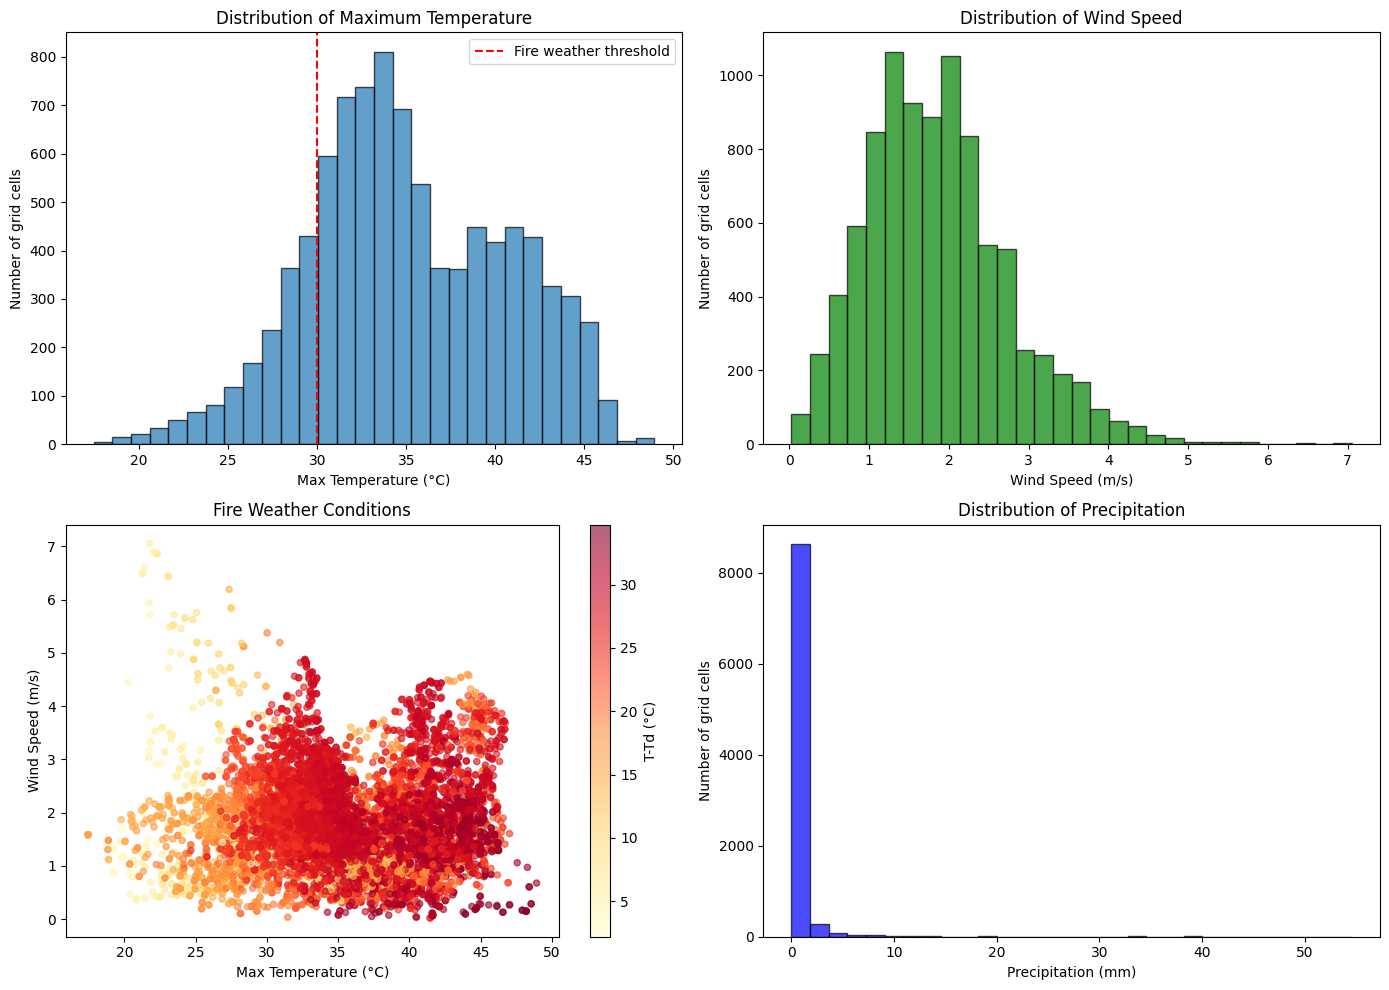


🔥 High fire risk areas: Hot + Dry + Windy (top-right in scatter plot)


In [15]:
# Visualize weather patterns
if len(weather_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Temperature distribution
    axes[0, 0].hist(weather_df['temp_max_C'], bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Max Temperature (°C)')
    axes[0, 0].set_ylabel('Number of grid cells')
    axes[0, 0].set_title('Distribution of Maximum Temperature')
    axes[0, 0].axvline(30, color='red', linestyle='--', label='Fire weather threshold')
    axes[0, 0].legend()
    
    # Wind speed distribution
    axes[0, 1].hist(weather_df['wind_speed_ms'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].set_xlabel('Wind Speed (m/s)')
    axes[0, 1].set_ylabel('Number of grid cells')
    axes[0, 1].set_title('Distribution of Wind Speed')
    
    # Temperature vs wind (fire weather)
    scatter = axes[1, 0].scatter(
        weather_df['temp_max_C'], 
        weather_df['wind_speed_ms'],
        c=weather_df['temp_dewpoint_diff'],
        cmap='YlOrRd',
        alpha=0.6,
        s=20
    )
    axes[1, 0].set_xlabel('Max Temperature (°C)')
    axes[1, 0].set_ylabel('Wind Speed (m/s)')
    axes[1, 0].set_title('Fire Weather Conditions')
    plt.colorbar(scatter, ax=axes[1, 0], label='T-Td (°C)')
    
    # Precipitation
    axes[1, 1].hist(weather_df['precip_mm'], bins=30, edgecolor='black', alpha=0.7, color='blue')
    axes[1, 1].set_xlabel('Precipitation (mm)')
    axes[1, 1].set_ylabel('Number of grid cells')
    axes[1, 1].set_title('Distribution of Precipitation')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔥 High fire risk areas: Hot + Dry + Windy (top-right in scatter plot)")

---
## Step 3: Extract Vegetation Features (NDVI)

**NDVI** (Normalized Difference Vegetation Index) measures vegetation greenness.

**Formula**: NDVI = (NIR - Red) / (NIR + Red)
- NIR = Near-Infrared reflectance
- Red = Red reflectance

**Values**:
- NDVI < 0.2: Bare soil, rocks
- NDVI 0.2-0.5: Sparse vegetation (grassland)
- NDVI > 0.5: Dense vegetation (forest)

**Why it matters for fires**:
- High NDVI = more fuel available
- BUT: Very high NDVI = moist/healthy vegetation → lower risk
- **Key metric**: Change in NDVI (drought indicator)

In [16]:
def extract_ndvi_for_date(date_str, grid_cells, bbox):
    """
    Extract NDVI for all grid cells on a specific date.
    
    Note: MODIS NDVI is 16-day composite, so we get the most recent available.
    
    Returns:
    --------
    ee.FeatureCollection
        NDVI values for each grid cell
    """
    
    # Load MODIS NDVI (MOD13A1 = 500m resolution, 16-day composite)
    # We'll use the most recent composite before the target date
    ndvi_collection = ee.ImageCollection('MODIS/061/MOD13A1') \
        .filterDate(
            ee.Date(date_str).advance(-30, 'day'),  # Look back 30 days
            date_str
        ) \
        .filterBounds(ee.Geometry.Rectangle(bbox)) \
        .select('NDVI')  # NDVI band (values: -2000 to 10000, scale factor 0.0001)
    
    # Get most recent image
    # .sort() orders by acquisition date, .first() gets newest
    ndvi_image = ndvi_collection.sort('system:time_start', False).first()
    
    # Scale NDVI to -1 to 1 range
    # Raw values are -2000 to 10000, multiply by 0.0001
    ndvi_scaled = ndvi_image.multiply(0.0001).rename('ndvi')
    
    # Convert grid to points
    grid_points = []
    for idx, row in grid_cells.iterrows():
        point = ee.Geometry.Point([row['lon_center'], row['lat_center']])
        feature = ee.Feature(point, {'cell_id': row['cell_id']})
        grid_points.append(feature)
    
    grid_fc = ee.FeatureCollection(grid_points)
    
    # Sample NDVI at grid points
    sampled = ndvi_scaled.sampleRegions(
        collection=grid_fc,
        scale=500,  # 500m native resolution
        geometries=False
    )
    
    return sampled

# Extract NDVI
print(f"\nExtracting NDVI for {test_date}...")
ndvi_data = extract_ndvi_for_date(test_date, grid, CA_BBOX)

print(f"✅ NDVI features extracted")
print(f"   Processing {ndvi_data.size().getInfo()} grid cells")


Extracting NDVI for 2020-08-20...
✅ NDVI features extracted
   Processing 9130 grid cells


### 🧠 **Understanding NDVI Extraction**

**Why 16-day composite?**
- MODIS passes over each location every 1-2 days
- But clouds often obscure the view
- 16-day composite = best cloud-free pixel from 16 days

**Why look back 30 days?**
- If exact date not available, get most recent
- NDVI changes slowly (vegetation doesn't green/brown overnight)
- A week-old NDVI is still informative

**Scaling**:
- Raw NDVI stored as integers (-2000 to 10000) to save space
- Multiply by 0.0001 to get actual values (-0.2 to 1.0)
- Negative values = water, snow, clouds

**Resolution mismatch**:
- NDVI: 500m
- Our grid: 10km
- Sampling averages all 500m pixels within each 10km cell


✅ NDVI data downloaded: 9130 records

Sample NDVI values:
  system:index    cell_id    ndvi                                    .geo
0        298_0  CA_000298  0.8274  {"type":"MultiPoint","coordinates":[]}
1        299_0  CA_000299  0.5034  {"type":"MultiPoint","coordinates":[]}
2        300_0  CA_000300  0.9019  {"type":"MultiPoint","coordinates":[]}
3        301_0  CA_000301  0.9146  {"type":"MultiPoint","coordinates":[]}
4        302_0  CA_000302  0.7084  {"type":"MultiPoint","coordinates":[]}

📊 NDVI Statistics:
   Mean: 0.299
   Min: -0.195 (bare/sparse)
   Max: 0.964 (dense vegetation)


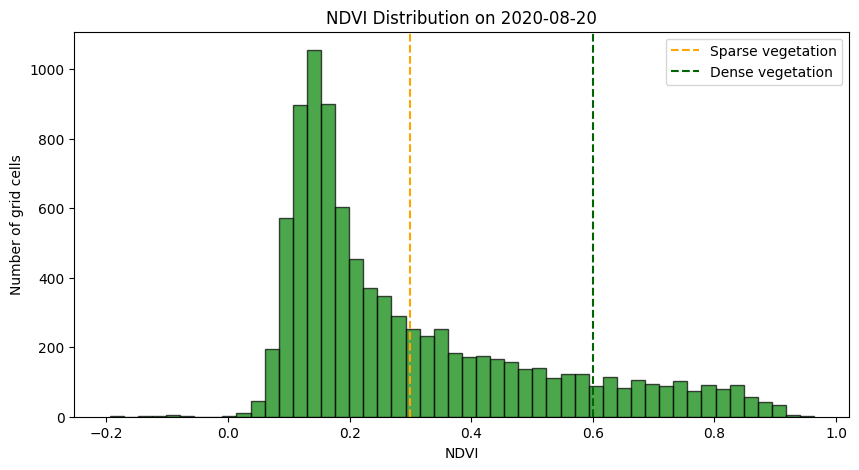

In [20]:
# Download NDVI data
try:
    ndvi_list = ndvi_data.getInfo()
    
    ndvi_records = []
    for feature in ndvi_list['features']:
        props = feature['properties']
        ndvi_records.append({
            'cell_id': props['cell_id'],
            'date': test_date,
            'ndvi': props.get('ndvi')
        })
    
    ndvi_df = pd.DataFrame(ndvi_records)
except Exception as e:
    print(f"⚠️  Download failed: {e}")
    print("🔄 Switching to export method...\n")
    task = ee.batch.Export.table.toDrive(
        collection=ndvi_data,
        description=f'ndvi_{test_date.replace("-", "_")}',
        folder='wildfire_data',
        fileFormat='CSV'
    )
    task.start()
    print("Download from drive and paste in folder")
    input("\nPress Enter after downloading the file...")
    ndvi_df = pd.read_csv('/home/krithi/Desktop/wildfire-prediction/files/data/ndvi_2020_08_20.csv')
    ndvi_df['date'] = test_date

# ndvi_df = pd.read_csv('/home/krithi/Desktop/wildfire-prediction/files/data/ndvi_2020_08_20.csv')    
print(f"\n✅ NDVI data downloaded: {len(ndvi_df)} records")
print(f"\nSample NDVI values:")
print(ndvi_df.head())

# Statistics
print(f"\n📊 NDVI Statistics:")
print(f"   Mean: {ndvi_df['ndvi'].mean():.3f}")
print(f"   Min: {ndvi_df['ndvi'].min():.3f} (bare/sparse)")
print(f"   Max: {ndvi_df['ndvi'].max():.3f} (dense vegetation)")

# Visualize
plt.figure(figsize=(10, 5))
plt.hist(ndvi_df['ndvi'], bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('NDVI')
plt.ylabel('Number of grid cells')
plt.title(f'NDVI Distribution on {test_date}')
plt.axvline(0.3, color='orange', linestyle='--', label='Sparse vegetation')
plt.axvline(0.6, color='darkgreen', linestyle='--', label='Dense vegetation')
plt.legend()
plt.show()



---
## Step 4: Extract Topography Features

Topography affects fire behavior:
- **Slope**: Fire spreads faster uphill (preheats fuel)
- **Aspect**: South-facing slopes (Northern Hemisphere) dry faster
- **Elevation**: Temperature decreases with altitude

In [21]:
def extract_topography(grid_cells, bbox):
    """
    Extract topographic features for all grid cells.
    
    Note: Topography is static (doesn't change over time),
    so we only need to extract it once.
    
    Returns:
    --------
    ee.FeatureCollection
        Elevation, slope, aspect for each grid cell
    """
    
    # Load SRTM elevation (30m resolution)
    elevation = ee.Image('USGS/SRTMGL1_003')
    
    # Calculate slope (in degrees)
    # Uses finite difference approximation on elevation
    slope = ee.Terrain.slope(elevation)
    
    # Calculate aspect (direction of slope, in degrees from north)
    # 0° = north, 90° = east, 180° = south, 270° = west
    aspect = ee.Terrain.aspect(elevation)
    
    # Combine into single image
    topo = ee.Image.cat([
        elevation.rename('elevation'),
        slope.rename('slope'),
        aspect.rename('aspect')
    ])
    
    # Convert grid to points
    grid_points = []
    for idx, row in grid_cells.iterrows():
        point = ee.Geometry.Point([row['lon_center'], row['lat_center']])
        feature = ee.Feature(point, {'cell_id': row['cell_id']})
        grid_points.append(feature)
    
    grid_fc = ee.FeatureCollection(grid_points)
    
    # Sample topography at grid points
    sampled = topo.sampleRegions(
        collection=grid_fc,
        scale=90,  # 90m for faster processing (can use 30m for final model)
        geometries=False
    )
    
    return sampled

# Extract topography (once, since it's static)
print("\nExtracting topography...")
topo_data = extract_topography(grid, CA_BBOX)

print(f"✅ Topography features extracted")
print(f"   Processing {topo_data.size().getInfo()} grid cells")


Extracting topography...
✅ Topography features extracted
   Processing 10539 grid cells



✅ Topography data downloaded: 10539 records

Sample topography:
  system:index  aspect    cell_id  elevation  slope  \
0         73_0    -0.0  CA_000073          0    0.0   
1         74_0    -0.0  CA_000074          0    0.0   
2         75_0    -0.0  CA_000075          0    0.0   
3         76_0    -0.0  CA_000076          0    0.0   
4         77_0    -0.0  CA_000077          0    0.0   

                                     .geo  aspect_sin  aspect_cos  
0  {"type":"MultiPoint","coordinates":[]}        -0.0         1.0  
1  {"type":"MultiPoint","coordinates":[]}        -0.0         1.0  
2  {"type":"MultiPoint","coordinates":[]}        -0.0         1.0  
3  {"type":"MultiPoint","coordinates":[]}        -0.0         1.0  
4  {"type":"MultiPoint","coordinates":[]}        -0.0         1.0  

📊 Topography Statistics:
   Mean elevation: 1032 m
   Mean slope: 7.4°
   Max slope: 60.2°


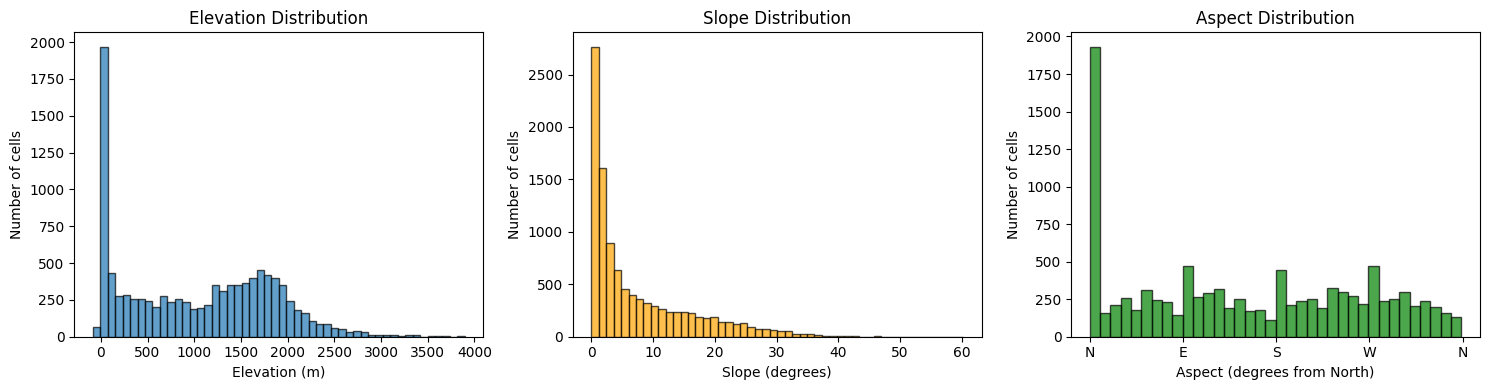

In [26]:
# Download topography data
# try:
#     topo_list = topo_data.getInfo()
    
#     topo_records = []
#     for feature in topo_list['features']:
#         props = feature['properties']
#         topo_records.append({
#             'cell_id': props['cell_id'],
#             'elevation_m': props.get('elevation'),
#             'slope_deg': props.get('slope'),
#             'aspect_deg': props.get('aspect')
#         })
    
#     topo_df = pd.DataFrame(topo_records)

# except Exception as e:
#     print(f"⚠️  Download failed: {e}")
#     print("🔄 Switching to export method...\n")
#     task = ee.batch.Export.table.toDrive(
#         collection=topo_data,
#         description='topography_static',
#         folder='wildfire_data',
#         fileFormat='CSV'
#     )
#     task.start()
#     print("Download from drive and paste in folder")
#     input("\nPress Enter after downloading the file...")
    
#     topo_df = pd.read_csv('/home/krithi/Desktop/wildfire-prediction/files/data/topography_static.csv')
    
# Create cyclical encoding for aspect
# Aspect is circular: 359° is next to 0°
topo_df['aspect_sin'] = np.sin(np.radians(topo_df['aspect']))
topo_df['aspect_cos'] = np.cos(np.radians(topo_df['aspect']))

print(f"\n✅ Topography data downloaded: {len(topo_df)} records")
print(f"\nSample topography:")
print(topo_df.head())

# Statistics
print(f"\n📊 Topography Statistics:")
print(f"   Mean elevation: {topo_df['elevation'].mean():.0f} m")
print(f"   Mean slope: {topo_df['slope'].mean():.1f}°")
print(f"   Max slope: {topo_df['slope'].max():.1f}°")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Elevation
axes[0].hist(topo_df['elevation'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Elevation (m)')
axes[0].set_ylabel('Number of cells')
axes[0].set_title('Elevation Distribution')

# Slope
axes[1].hist(topo_df['slope'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Slope (degrees)')
axes[1].set_ylabel('Number of cells')
axes[1].set_title('Slope Distribution')

# Aspect (circular histogram)
axes[2].hist(topo_df['aspect'], bins=36, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Aspect (degrees from North)')
axes[2].set_ylabel('Number of cells')
axes[2].set_title('Aspect Distribution')
axes[2].set_xticks([0, 90, 180, 270, 360])
axes[2].set_xticklabels(['N', 'E', 'S', 'W', 'N'])

plt.tight_layout()
plt.show()


In [29]:
topo_df.describe()

,aspect,elevation,slope,aspect_sin,aspect_cos
count,10539.000000,10539.000000,10539.000000,10539.000000,10539.000000
mean,149.545718,1032.330297,7.420106,-0.012131,0.124840
std,112.307502,806.252855,8.555699,0.677494,0.724819
min,-0.000000,-84.000000,0.000000,-1.000000,-1.000000
25%,43.411695,204.000000,1.111805,-0.677035,-0.600477
50%,142.936770,1063.000000,3.614530,0.000000,0.155871
75%,250.592490,1701.000000,11.609821,0.646782,0.901391
max,358.921940,3896.000000,60.185090,1.000000,1.000000


### 🧠 **Understanding Topography**

**Elevation**:
- Higher elevation → cooler temperatures
- But also different vegetation types

**Slope**:
- Steep slopes → faster fire spread uphill
- Fire spreads 2-3x faster uphill than on flat ground

**Aspect (direction)**:
- South-facing (180°) → more sun exposure → drier
- North-facing (0°) → less sun → moister
- Must encode as sin/cos (circular variable)

**Why sin/cos encoding?**
- Raw aspect: 359° seems far from 1°, but they're adjacent!
- Sin/cos: sin(359°) ≈ sin(1°), cos(359°) ≈ cos(1°)
- Model can learn circular relationships

---
## Step 5: Merge All Features

Now we combine weather, NDVI, and topography into a single dataset.

In [37]:
# Merge datasets
# Start with weather (has date)
features = weather_df.copy()
# Make sure weather has a date column
if 'date' not in features.columns:
    features['date'] = test_date

# Add NDVI (merge on cell_id only)
features = features.merge(
    ndvi_df[['cell_id', 'ndvi']], 
    on='cell_id', 
    how='left'
)
# Add NDVI (also has date)
# features = features.merge(ndvi_df, on=['cell_id', 'date'], how='left')

# Add topography (no date, static)
features = features.merge(topo_df, on='cell_id', how='left')

print(f"\n✅ Features merged: {len(features)} records")
print(f"\nFeature columns: {list(features.columns)}")
print(f"\nSample record:")
print(features.head(1).T)  # Transpose for readability


✅ Features merged: 9137 records

Feature columns: ['system:index_x', 'cell_id', 'dewpoint_K', 'precip_m', 'temp_max_K', 'temp_mean_K', 'wind_speed_ms', '.geo_x', 'temp_mean_C', 'temp_max_C', 'dewpoint_C', 'temp_dewpoint_diff', 'precip_mm', 'date', 'ndvi', 'system:index_y', 'aspect', 'elevation', 'slope', '.geo_y', 'aspect_sin', 'aspect_cos']

Sample record:
                                                         0
system:index_x                                       299_0
cell_id                                          CA_000299
dewpoint_K                                       285.07932
precip_m                                          0.000088
temp_max_K                                      294.900482
temp_mean_K                                     289.300709
wind_speed_ms                                     3.165711
.geo_x              {"type":"MultiPoint","coordinates":[]}
temp_mean_C                                      16.150709
temp_max_C                                       

### 🧠 **Understanding Joins**

**Merge types**:
- **Inner join** (`how='inner'`): Keep only rows present in both tables
- **Left join** (`how='left'`): Keep all rows from left table, fill NaN if missing in right
- **Outer join** (`how='outer'`): Keep all rows from both tables

**Why left join?**
- Weather is our "anchor" (has date)
- NDVI might be missing (clouds), but we still want the weather row
- Topography should never be missing (static)

**Join keys**:
- Weather + NDVI: Join on `cell_id` AND `date` (spatiotemporal)
- Topography: Join only on `cell_id` (spatial only)

---
## Step 6: Add Fire Target

Now we need to add whether a fire occurred in each cell. 
We'll load the fires from Phase 1 and label cells as fire/no-fire.

In [38]:
# Load fire data from Phase 1
fires_df = pd.read_csv(f'../data/fires_{test_date}.csv')

print(f"✅ Loaded {len(fires_df)} fire detections")
print(fires_df.head())

✅ Loaded 2060 fire detections
          lon        lat  fire_mask        date
0 -120.280835  42.106682          8  2020-08-20
1 -120.268714  42.106682          8  2020-08-20
2 -123.397491  41.234341          7  2020-08-20
3 -123.392475  41.225348          7  2020-08-20
4 -123.380518  41.225348          8  2020-08-20


In [39]:
# Convert fires to GeoDataFrame
from shapely.geometry import Point

fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=[Point(lon, lat) for lon, lat in zip(fires_df['lon'], fires_df['lat'])],
    crs='EPSG:4326'
)

# Load grid (we need the geometry for spatial join)
grid_gdf = gpd.read_parquet('../data/grid_10km.parquet')

# Spatial join: which grid cell contains each fire?
fires_with_cells = gpd.sjoin(fires_gdf, grid_gdf, how='left', predicate='within')

print(f"\n✅ Matched fires to grid cells")
print(f"   {len(fires_with_cells)} fires assigned to cells")
print(fires_with_cells[['lat', 'lon', 'cell_id', 'fire_mask']].head())


✅ Matched fires to grid cells
   2060 fires assigned to cells
         lat         lon    cell_id  fire_mask
0  42.106682 -120.280835        NaN          8
1  42.106682 -120.268714        NaN          8
2  41.234341 -123.397491  CA_001369          7
3  41.225348 -123.392475  CA_001369          7
4  41.225348 -123.380518  CA_001369          8


### 🧠 **Understanding Spatial Join**

**What `sjoin` does**:
1. For each fire point
2. Find which grid polygon contains it
3. Add that polygon's attributes to the fire row

**Predicate options**:
- `'within'`: Point is inside polygon
- `'intersects'`: Point touches polygon (includes boundary)
- `'contains'`: Reverse of within

**Result**:
- Each fire now has a `cell_id`
- We can count fires per cell

In [40]:
# Check how many fires are outside the grid
print(f"Total fires: {len(fires_with_cells)}")
print(f"Fires WITH cell_id: {fires_with_cells['cell_id'].notna().sum()}")
print(f"Fires WITHOUT cell_id (NaN): {fires_with_cells['cell_id'].isna().sum()}")

# Check the extent of fires vs grid
print("\n📍 Fire locations:")
print(f"  Lat range: {fires_gdf['lat'].min():.3f} to {fires_gdf['lat'].max():.3f}")
print(f"  Lon range: {fires_gdf['lon'].min():.3f} to {fires_gdf['lon'].max():.3f}")

print("\n📐 Grid extent:")
print(f"  Grid bounds: {grid_gdf.total_bounds}")  # [min_lon, min_lat, max_lon, max_lat]

# Show some fires with NaN
print("\n🔥 Fires outside grid (NaN cell_id):")
print(fires_with_cells[fires_with_cells['cell_id'].isna()][['lat', 'lon', 'fire_mask']].head(10))

Total fires: 2060
Fires WITH cell_id: 2058
Fires WITHOUT cell_id (NaN): 2

📍 Fire locations:
  Lat range: 34.642 to 42.107
  Lon range: -124.101 to -117.530

📐 Grid extent:
  Grid bounds: [-124.54504505   32.45495495 -114.0045045    42.0045045 ]

🔥 Fires outside grid (NaN cell_id):
         lat         lon  fire_mask
0  42.106682 -120.280835          8
1  42.106682 -120.268714          8


In [41]:
# Count fires per cell
fire_counts = fires_with_cells.groupby('cell_id').size().reset_index(name='fire_count')

# Create binary fire indicator
fire_counts['fire'] = 1  # Any fire = 1

print(f"\n📊 Fire Statistics:")
print(f"   Cells with fires: {len(fire_counts)}")
print(f"   Max fires in one cell: {fire_counts['fire_count'].max()}")
print(f"\nCells with most fires:")
print(fire_counts.nlargest(5, 'fire_count'))


📊 Fire Statistics:
   Cells with fires: 148
   Max fires in one cell: 63

Cells with most fires:
       cell_id  fire_count  fire
103  CA_003446          63     1
32   CA_002199          49     1
119  CA_003763          48     1
12   CA_001870          47     1
76   CA_002807          44     1


In [42]:
# Add fire labels to features
features = features.merge(
    fire_counts[['cell_id', 'fire']], 
    on='cell_id', 
    how='left'
)

# Fill NaN with 0 (no fire)
features['fire'] = features['fire'].fillna(0).astype(int)

print(f"\n✅ Fire labels added")
print(f"\n📊 Class Distribution:")
print(features['fire'].value_counts())
print(f"\nFire rate: {features['fire'].mean()*100:.2f}%")


✅ Fire labels added

📊 Class Distribution:
fire
0    8999
1     138
Name: count, dtype: int64

Fire rate: 1.51%


### 🧠 **The Class Imbalance Problem**

Notice: Only a tiny fraction of cells have fires!

This is **extreme class imbalance**:
- Fires: <1% of samples
- No fires: >99% of samples

**Why this matters**:
- Model can achieve 99% accuracy by always predicting "no fire"
- But we actually want to CATCH fires

**Solutions** (we'll implement in Phase 3):
1. Use appropriate metrics (AUPRC, not accuracy)
2. Class weighting (penalize missed fires more)
3. Threshold tuning (optimize for recall)

---
## Step 7: Create Temporal Features

Right now we only have one day. For a real model, we'd:
1. Extract features for many dates (e.g., entire fire season)
2. Create lag features (yesterday's weather)
3. Create rolling features (7-day average temperature)

**For this demo**, let's show the concept with dummy data.

In [43]:
# Create example temporal features
# In real implementation, you'd loop through dates and extract features

# For demonstration, let's create placeholders
features_with_lags = features.copy()

# These would normally be computed from previous days' data
features_with_lags['temp_lag1'] = np.nan  # Yesterday's temperature
features_with_lags['temp_lag7'] = np.nan  # Temperature 7 days ago
features_with_lags['temp_rolling7'] = np.nan  # 7-day average

features_with_lags['precip_7d_sum'] = np.nan  # Precipitation last 7 days
features_with_lags['precip_30d_sum'] = np.nan  # Precipitation last 30 days

features_with_lags['ndvi_change_30d'] = np.nan  # NDVI change (drought indicator)

features_with_lags['days_since_rain'] = np.nan  # Consecutive dry days

print("\n📝 Temporal features template created")
print("\nIn Phase 3, we'll extract multi-day data to populate these features.")
print("\nColumns:")
print(list(features_with_lags.columns))


📝 Temporal features template created

In Phase 3, we'll extract multi-day data to populate these features.

Columns:
['system:index_x', 'cell_id', 'dewpoint_K', 'precip_m', 'temp_max_K', 'temp_mean_K', 'wind_speed_ms', '.geo_x', 'temp_mean_C', 'temp_max_C', 'dewpoint_C', 'temp_dewpoint_diff', 'precip_mm', 'date', 'ndvi', 'system:index_y', 'aspect', 'elevation', 'slope', '.geo_y', 'aspect_sin', 'aspect_cos', 'fire', 'temp_lag1', 'temp_lag7', 'temp_rolling7', 'precip_7d_sum', 'precip_30d_sum', 'ndvi_change_30d', 'days_since_rain']


### 🧠 **How Temporal Features Would Work**

**Example: Creating lag features**

If we had data for multiple days:

```python
# Sort by cell and date
df = df.sort_values(['cell_id', 'date'])

# Create lag features (grouped by cell)
df['temp_lag1'] = df.groupby('cell_id')['temp_mean_C'].shift(1)
df['temp_lag7'] = df.groupby('cell_id')['temp_mean_C'].shift(7)

# Rolling features
df['temp_rolling7'] = df.groupby('cell_id')['temp_mean_C'] \
    .rolling(window=7, min_periods=1) \
    .mean() \
    .reset_index(drop=True)
```

**Why groupby?**
- Without it, cell A's yesterday becomes cell B's yesterday!
- Grouping ensures lags stay within the same spatial unit

---
## Step 8: Add Cyclical Time Features

Time has cycles (seasons, days of week). Encode them properly!

In [44]:
# Convert date to datetime
features_with_lags['date'] = pd.to_datetime(features_with_lags['date'])

# Extract time components
features_with_lags['day_of_year'] = features_with_lags['date'].dt.dayofyear
features_with_lags['month'] = features_with_lags['date'].dt.month
features_with_lags['day_of_week'] = features_with_lags['date'].dt.dayofweek

# Cyclical encoding for day of year
features_with_lags['doy_sin'] = np.sin(2 * np.pi * features_with_lags['day_of_year'] / 365)
features_with_lags['doy_cos'] = np.cos(2 * np.pi * features_with_lags['day_of_year'] / 365)

# Month encoding (also cyclical)
features_with_lags['month_sin'] = np.sin(2 * np.pi * features_with_lags['month'] / 12)
features_with_lags['month_cos'] = np.cos(2 * np.pi * features_with_lags['month'] / 12)

print("\n✅ Time features created")
print(f"\nDate: {test_date}")
print(f"Day of year: {features_with_lags['day_of_year'].iloc[0]}")
print(f"Month: {features_with_lags['month'].iloc[0]} (August)")
print(f"\nCyclical encodings:")
print(features_with_lags[['doy_sin', 'doy_cos', 'month_sin', 'month_cos']].iloc[0])


✅ Time features created

Date: 2020-08-20
Day of year: 233
Month: 8 (August)

Cyclical encodings:
doy_sin     -0.763889
doy_cos     -0.645348
month_sin   -0.866025
month_cos   -0.500000
Name: 0, dtype: float64


### 🧠 **Why Cyclical Encoding Matters**

**Problem with raw numbers**:
- December (12) and January (1) are 11 units apart
- But they're actually adjacent months!
- Model treats them as very different

**Solution: Sin/Cos encoding**:
```
January (1):   sin = 0.5,   cos = 0.87
December (12): sin = 0.5,   cos = 0.87
```
Now December and January are similar!

**Visualization**:
- Imagine a clock
- January = 1 o'clock
- December = 12 o'clock
- They're next to each other on the circle

**Formula**:
- `sin(2π × month / 12)` maps month to y-coordinate on unit circle
- `cos(2π × month / 12)` maps month to x-coordinate

---
## Step 9: Final Dataset Summary

In [46]:
# Clean up: Select final features
final_features = features_with_lags[[
    # Identifiers
    'cell_id', 'date',
    
    # Weather
    'temp_mean_C', 'temp_max_C', 'dewpoint_C', 'temp_dewpoint_diff',
    'wind_speed_ms', 'precip_mm',
    
    # Vegetation
    'ndvi',
    
    # Topography
    'elevation', 'slope', 'aspect_sin', 'aspect_cos',
    
    # Time
    'day_of_year', 'month', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos',
    
    # Target
    'fire'
]]

print("\n✅ Final dataset prepared")
print(f"\nShape: {final_features.shape}")
print(f"Rows: {final_features.shape[0]:,}")
print(f"Features: {final_features.shape[1] - 3} (excluding cell_id, date, fire)")

print("\n📊 Dataset Summary:")
print(final_features.describe())

# Check for missing values
missing = final_features.isnull().sum()
if missing.sum() > 0:
    print("\n⚠️  Missing values:")
    print(missing[missing > 0])
else:
    print("\n✅ No missing values")


✅ Final dataset prepared

Shape: (9137, 20)
Rows: 9,137
Features: 17 (excluding cell_id, date, fire)

📊 Dataset Summary:
                      date  temp_mean_C   temp_max_C   dewpoint_C  \
count                 9137  9137.000000  9137.000000  9137.000000   
mean   2020-08-20 00:00:00    28.255777    35.071790     4.013821   
min    2020-08-20 00:00:00    12.567213    17.445795    -6.953005   
25%    2020-08-20 00:00:00    24.799065    31.250864     0.065631   
50%    2020-08-20 00:00:00    27.895745    34.418878     2.873411   
75%    2020-08-20 00:00:00    31.839674    39.489191     6.387653   
max    2020-08-20 00:00:00    43.869947    48.928644    23.027546   
std                    NaN     5.424968     5.554542     5.156532   

       temp_dewpoint_diff  wind_speed_ms    precip_mm         ndvi  \
count         9137.000000    9137.000000  9137.000000  9076.000000   
mean            24.241956       1.856431     0.593711     0.297457   
min              2.201532       0.023509     0

In [47]:
# Save to file
output_file = f'../data/features_sample_{test_date}.csv'
final_features.to_csv(output_file, index=False)

print(f"\n💾 Dataset saved to: {output_file}")
print(f"\nReady for modeling! 🎉")


💾 Dataset saved to: ../data/features_sample_2020-08-20.csv

Ready for modeling! 🎉


---
## Step 10: Feature Correlations

Let's check which features are correlated with fire occurrence.


📊 Feature Correlations with Fire Occurrence:

Top positive correlations (higher value → more fire):
ndvi                  0.146784
slope                 0.094559
wind_speed_ms         0.015347
aspect_cos           -0.000946
aspect_sin           -0.004761
dewpoint_C           -0.006855
precip_mm            -0.025575
temp_max_C           -0.036354
temp_dewpoint_diff   -0.059234
elevation            -0.068368
Name: fire, dtype: float64

Top negative correlations (higher value → less fire):
temp_max_C           -0.036354
temp_dewpoint_diff   -0.059234
elevation            -0.068368
temp_mean_C          -0.071671
day_of_year                NaN
month                      NaN
doy_sin                    NaN
doy_cos                    NaN
month_sin                  NaN
month_cos                  NaN
Name: fire, dtype: float64


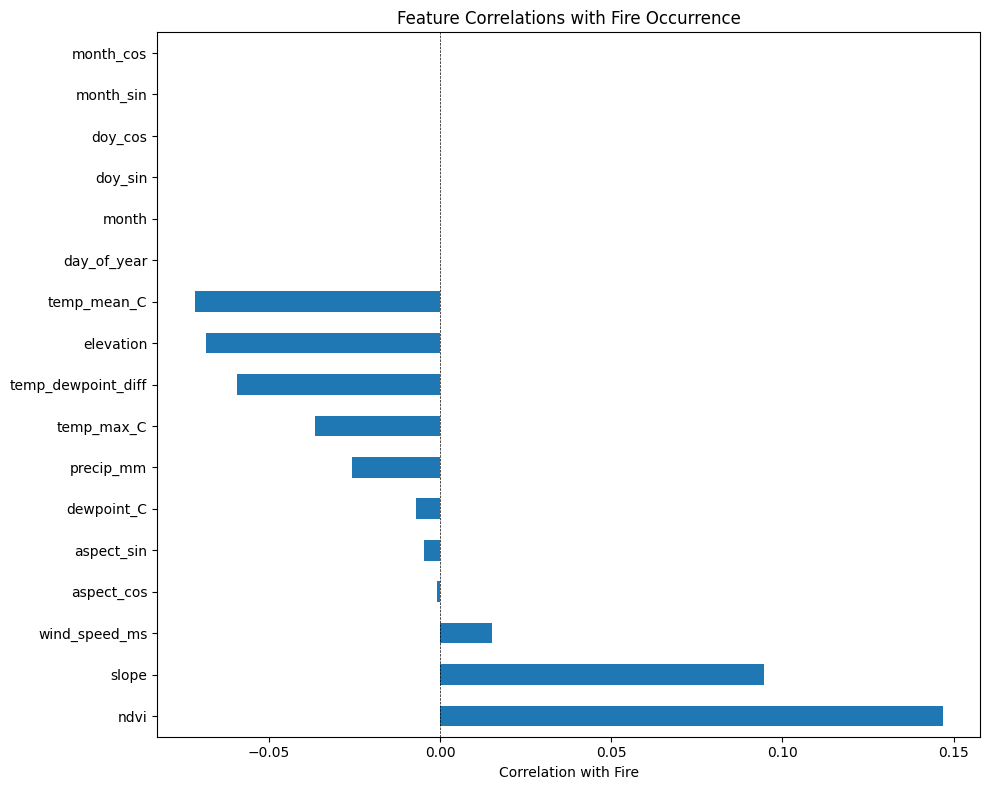

In [48]:
# Calculate correlations with fire target
# Only use numeric features
numeric_features = final_features.select_dtypes(include=[np.number]).columns
numeric_features = [col for col in numeric_features if col not in ['cell_id', 'fire']]

correlations = final_features[numeric_features + ['fire']].corr()['fire'].sort_values(ascending=False)

print("\n📊 Feature Correlations with Fire Occurrence:")
print("\nTop positive correlations (higher value → more fire):")
print(correlations[1:11])  # Top 10, excluding 'fire' itself

print("\nTop negative correlations (higher value → less fire):")
print(correlations[-10:])

# Visualize
plt.figure(figsize=(10, 8))
correlations[1:].plot(kind='barh')  # Exclude 'fire' itself
plt.xlabel('Correlation with Fire')
plt.title('Feature Correlations with Fire Occurrence')
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 🧠 **Interpreting Correlations**

**What correlations tell us**:
- Positive: Higher value → more likely to have fire
- Negative: Higher value → less likely to have fire

**Expected patterns** (based on fire science):
- ✅ High temperature → more fires
- ✅ Low humidity (high temp-dewpoint diff) → more fires
- ✅ High wind → more fires
- ✅ Low precipitation → more fires

**Caution**:
- Correlation ≠ causation
- These are linear correlations (model can learn non-linear patterns)
- Interactions matter (e.g., high temp + low humidity)

**If correlations are weak**:
- Could mean: non-linear relationships
- Could mean: interactions dominate
- Could mean: small sample size (only 1 day)

---
## 📚 Summary: What We Built

### ✅ Data Sources Integrated:
1. **Weather**: ERA5-Land (temperature, humidity, wind, precipitation)
2. **Vegetation**: MODIS NDVI (fuel availability)
3. **Topography**: SRTM (elevation, slope, aspect)
4. **Fires**: MODIS fire detections (target variable)

### ✅ Features Created:
- **Meteorological**: 6 features (temp mean/max, dewpoint, diff, wind, precip)
- **Vegetation**: 1 feature (ndvi)
- **Topographic**: 4 features (elevation, slope, aspect sin/cos)
- **Temporal**: 6 features (doy, month, cyclical encodings)
- **Total**: 17 features + target

### ✅ Key Techniques Learned:
1. Multi-source data extraction from Earth Engine
2. Spatial joins (fires to grid cells)
3. Cyclical encoding (time and aspect)
4. Feature engineering for spatial ML

### 🎯 Next Steps:

**Phase 3** will cover:
1. **Expanding temporal coverage** - Extract features for entire fire season (June-October)
2. **Creating lag features** - Yesterday's weather, last week's NDVI
3. **Training models** - Gradient boosting with class imbalance handling
4. **Validation** - Temporal and spatial cross-validation
5. **Evaluation** - AUPRC, precision-recall curves, feature importance

---

**Great work! You now understand the full feature engineering pipeline. 🚀**

In [49]:

# Your extraction functions from Phase 2
# def extract_features_for_date(date_str, grid, bbox):
#     \"\"\"Extract weather, NDVI, fires for one date.\"\"\"
#     # ... (same code from Phase 2)
#     return features_df

# Date range
dates = pd.date_range('2020-08-18', '2020-08-24', freq='D')

# Loop and export
for date in tqdm(dates):
    date_str = date.strftime('%Y-%m-%d')
    
    # Start exports (they run async)
    # Weather
    weather_task = ee.batch.Export.table.toDrive(
        collection=extract_weather(date_str, grid, bbox),
        description=f'weather_{date_str.replace("-", "_")}',
        folder='wildfire_week',
        fileFormat='CSV'
    )
    weather_task.start()
    
    # NDVI  
    ndvi_task = ee.batch.Export.table.toDrive(
        collection=extract_ndvi(date_str, grid, bbox),
        description=f'ndvi_{date_str.replace("-", "_")}',
        folder='wildfire_week',
        fileFormat='CSV'
    )
    ndvi_task.start()
    
    print(f"✅ Exports started for {date_str}")

print("\n⏳ Wait 5-10 minutes, then download from Google Drive")

  0%|                                                     | 0/7 [00:00<?, ?it/s]


NameError: name 'extract_weather' is not defined

In [2]:
# ========================================
# MULTI-DATE BATCH EXPORT CODE
# Add this to Phase 2 notebook (after single date extraction)
# ========================================

# Load grid and static data
grid_gdf = gpd.read_parquet('../data/grid_10km.parquet')
CA_BBOX = [-124.5, 32.5, -114.0, 42.0]

print("✅ Setup complete")
print(f"Grid: {len(grid_gdf)} cells")

# ========================================
# STEP 1: Define Date Range
# ========================================

# Option A: One week (for testing)
start_date = '2020-08-01'
end_date = '2020-08-31'

# Option B: One month (recommended for portfolio)
# start_date = '2020-08-01'
# end_date = '2020-08-31'

# Option C: Full fire season (best results)
# start_date = '2020-06-01'
# end_date = '2020-10-31'

# Generate date range
date_range = pd.date_range(start_date, end_date, freq='D')

print(f"\n📅 Will process {len(date_range)} dates:")
print(f"   From: {date_range[0].strftime('%Y-%m-%d')}")
print(f"   To:   {date_range[-1].strftime('%Y-%m-%d')}")

# ========================================
# STEP 2: Create Extraction Functions
# ========================================

def extract_weather_for_date(date_str, grid_cells, bbox):
    """
    Extract weather features for a specific date.
    Returns: ee.FeatureCollection
    """
    era5 = ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY') \
        .filterDate(date_str, ee.Date(date_str).advance(1, 'day')) \
        .filterBounds(ee.Geometry.Rectangle(bbox))
    
    weather = era5.select([
        'temperature_2m',
        'dewpoint_temperature_2m',
        'u_component_of_wind_10m',
        'v_component_of_wind_10m',
        'total_precipitation'
    ])
    
    # Daily aggregates
    temp_mean = weather.select('temperature_2m').mean()
    temp_max = weather.select('temperature_2m').max()
    dewpoint_mean = weather.select('dewpoint_temperature_2m').mean()
    
    u = weather.select('u_component_of_wind_10m').mean()
    v = weather.select('v_component_of_wind_10m').mean()
    wind_speed = u.pow(2).add(v.pow(2)).sqrt()
    
    precip = weather.select('total_precipitation').sum()
    
    weather_composite = ee.Image.cat([
        temp_mean.rename('temp_mean'),
        temp_max.rename('temp_max'),
        dewpoint_mean.rename('dewpoint'),
        wind_speed.rename('wind_speed'),
        precip.rename('precip')
    ])
    
    # Create points for sampling
    grid_points = [
        ee.Feature(
            ee.Geometry.Point([row['lon_center'], row['lat_center']]),
            {'cell_id': row['cell_id']}
        )
        for idx, row in grid_cells.iterrows()
    ]
    grid_fc = ee.FeatureCollection(grid_points)
    
    sampled = weather_composite.sampleRegions(
        collection=grid_fc,
        scale=9000,
        geometries=False
    )
    
    return sampled


def extract_ndvi_for_date(date_str, grid_cells, bbox):
    """
    Extract NDVI for a specific date.
    Returns: ee.FeatureCollection
    """
    ndvi_collection = ee.ImageCollection('MODIS/061/MOD13A1') \
        .filterDate(
            ee.Date(date_str).advance(-30, 'day'),
            date_str
        ) \
        .filterBounds(ee.Geometry.Rectangle(bbox)) \
        .select('NDVI')
    
    ndvi_image = ndvi_collection.sort('system:time_start', False).first()
    ndvi_scaled = ndvi_image.multiply(0.0001).rename('ndvi')
    
    grid_points = [
        ee.Feature(
            ee.Geometry.Point([row['lon_center'], row['lat_center']]),
            {'cell_id': row['cell_id']}
        )
        for idx, row in grid_cells.iterrows()
    ]
    grid_fc = ee.FeatureCollection(grid_points)
    
    sampled = ndvi_scaled.sampleRegions(
        collection=grid_fc,
        scale=500,
        geometries=False
    )
    
    return sampled

print("\n✅ Extraction functions defined")

# ========================================
# STEP 3: Submit Export Tasks (All Dates)
# ========================================

print("\n" + "="*60)
print("STARTING BATCH EXPORTS")
print("="*60)
print("\nThis will submit export tasks to Google Earth Engine.")
print("Tasks run asynchronously - you can close this notebook.")
print("Check progress at: https://code.earthengine.google.com/ → Tasks\n")

# Ask for confirmation
proceed = input("Submit exports for all dates? (yes/no): ")

if proceed.lower() != 'yes':
    print("❌ Cancelled. Change date range and try again.")
else:
    # Submit all export tasks
    tasks_submitted = []
    
    for date in tqdm(date_range, desc="Submitting exports"):
        date_str = date.strftime('%Y-%m-%d')
        date_filename = date.strftime('%Y_%m_%d')
        
        try:
            # Weather export
            weather_fc = extract_weather_for_date(date_str, grid_gdf, CA_BBOX)
            
            task_weather = ee.batch.Export.table.toDrive(
                collection=weather_fc,
                description=f'weather_{date_filename}',
                folder='wildfire_data_batch',
                fileFormat='CSV'
            )
            task_weather.start()
            tasks_submitted.append(('weather', date_str, task_weather))
            
            # NDVI export
            ndvi_fc = extract_ndvi_for_date(date_str, grid_gdf, CA_BBOX)
            
            task_ndvi = ee.batch.Export.table.toDrive(
                collection=ndvi_fc,
                description=f'ndvi_{date_filename}',
                folder='wildfire_data_batch',
                fileFormat='CSV'
            )
            task_ndvi.start()
            tasks_submitted.append(('ndvi', date_str, task_ndvi))
            
            # Small delay to avoid overwhelming API
            time.sleep(0.5)
            
        except Exception as e:
            print(f"\n⚠️  Error submitting {date_str}: {e}")
    
    print(f"\n✅ All export tasks submitted!")
    print(f"   Total tasks: {len(tasks_submitted)}")
    print(f"   Weather exports: {len([t for t in tasks_submitted if t[0] == 'weather'])}")
    print(f"   NDVI exports: {len([t for t in tasks_submitted if t[0] == 'ndvi'])}")
    
    print("\n" + "="*60)
    print("NEXT STEPS:")
    print("="*60)
    print("\n1. ⏳ Wait for exports to complete (10 min - 2 hours)")
    print("   • Check status: https://code.earthengine.google.com/ → Tasks")
    print("   • All tasks should show 'Completed' status")
    
    print("\n2. 📥 Download files from Google Drive:")
    print("   • Go to: https://drive.google.com/")
    print("   • Open folder: wildfire_data_batch")
    print("   • Download all CSVs (or entire folder)")
    
    print("\n3. 💾 Save to project directory:")
    print("   • Create folder: data/multi_date/")
    print("   • Move all downloaded CSVs there")
    print("   • Files should be named: weather_2020_08_18.csv, ndvi_2020_08_18.csv, etc.")
    
    print("\n4. 🚀 Run Phase 3 notebook to process and model!")
    
    print("\n" + "="*60)

# ========================================
# OPTIONAL: Monitor Progress
# ========================================

monitor = input("\nMonitor export progress? (yes/no): ")

if monitor.lower() == 'yes' and len(tasks_submitted) > 0:
    print("\n📊 Monitoring export progress...")
    print("(Press Ctrl+C to stop monitoring)\n")
    
    try:
        while True:
            statuses = {}
            for task_type, date_str, task in tasks_submitted:
                status = task.status()['state']
                if status not in statuses:
                    statuses[status] = 0
                statuses[status] += 1
            
            print(f"Status: ", end='')
            for state, count in sorted(statuses.items()):
                print(f"{state}={count}  ", end='')
            print("", end='\r')
            
            # Check if all complete
            if 'RUNNING' not in statuses and 'READY' not in statuses:
                print("\n\n✅ All exports completed!")
                print("\nFinal status:")
                for state, count in sorted(statuses.items()):
                    print(f"   {state}: {count} tasks")
                break
            
            time.sleep(10)  # Check every 10 seconds
            
    except KeyboardInterrupt:
        print("\n\n⏸️  Monitoring stopped (tasks still running in background)")
        print("Check status at: https://code.earthengine.google.com/")

print("\n" + "="*60)
print("BATCH EXPORT COMPLETE!")
print("="*60)

✅ Setup complete
Grid: 12402 cells

📅 Will process 31 dates:
   From: 2020-08-01
   To:   2020-08-31

✅ Extraction functions defined

STARTING BATCH EXPORTS

This will submit export tasks to Google Earth Engine.
Tasks run asynchronously - you can close this notebook.
Check progress at: https://code.earthengine.google.com/ → Tasks



Submit exports for all dates? (yes/no):  yes


Submitting exports: 100%|███████████████████████| 31/31 [30:38<00:00, 59.29s/it]


✅ All export tasks submitted!
   Total tasks: 62
   Weather exports: 31
   NDVI exports: 31

NEXT STEPS:

1. ⏳ Wait for exports to complete (10 min - 2 hours)
   • Check status: https://code.earthengine.google.com/ → Tasks
   • All tasks should show 'Completed' status

2. 📥 Download files from Google Drive:
   • Go to: https://drive.google.com/
   • Open folder: wildfire_data_batch
   • Download all CSVs (or entire folder)

3. 💾 Save to project directory:
   • Create folder: data/multi_date/
   • Move all downloaded CSVs there
   • Files should be named: weather_2020_08_18.csv, ndvi_2020_08_18.csv, etc.

4. 🚀 Run Phase 3 notebook to process and model!




Monitor export progress? (yes/no):  yes



📊 Monitoring export progress...
(Press Ctrl+C to stop monitoring)

Status: COMPLETED=62  READY=1  RUNNING=1   

✅ All exports completed!

Final status:
   COMPLETED: 62 tasks

BATCH EXPORT COMPLETE!
